# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

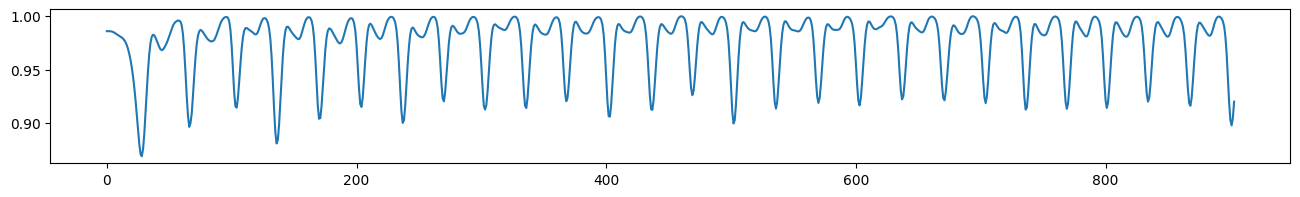

In [3]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

In [4]:
m = 20
matrix_profile = stumpy.stump(ts.astype(float), m)
profile_values = matrix_profile[:, 0]
profile_left_indices = matrix_profile[:, 2]
profile_right_indices = matrix_profile[:, 3]
count = np.ones(len(profile_values))
best_indices = []

for i in range(1, len(profile_right_indices)):
    if count[i] == 1:
        j = i
        cur_indices = [j]
        while profile_right_indices[j] != 0 and profile_left_indices[profile_right_indices[j]] == j:
            j = profile_right_indices[j]
            count[j] = -1
            count[i] = count[i] + 1
            cur_indices.append(j)
        if len(best_indices) < len(cur_indices):
            best_indices = np.copy(cur_indices)

print(best_indices)


[ 74 143 177 475 807 840]


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Была получена цепочка из 6 подпоследовательностей при размере окна в 20 элементов ряда

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

In [5]:
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import plotly.express as px

ts_len = ts.shape[0]

fig = make_subplots(rows=2, cols=1, horizontal_spacing=0.04)

for best in best_indices:
    fig.add_trace(go.Scatter(x=np.arange(best, best+m-1), y=ts[best:best+m-1], line=dict(color=px.colors.qualitative.Plotly[1])),
                row=1, col=1)
fig.add_trace(go.Scatter(x=np.arange(ts_len), y=ts, line=dict(color=px.colors.qualitative.Plotly[0])),
            row=1, col=1)

for best in best_indices:
    fig.add_trace(go.Scatter(x=np.arange(best, best+m-1), y=ts[best:best+m-1], line=dict(color=px.colors.qualitative.Plotly[1])),
                row=2, col=1)
fig.add_trace(go.Scatter(x=np.arange(ts_len), y=ts, opacity=0.0),
            row=2, col=1)

fig.update_annotations(font=dict(size=24, color='black'))

fig.update_xaxes(showgrid=False,
                    linecolor='#000',
                    ticks="outside",
                    tickfont=dict(size=18, color='black'),
                    linewidth=1,
                    tickwidth=1,
                    mirror=True)
fig.update_yaxes(showgrid=False,
                    linecolor='#000',
                    ticks="outside",
                    tickfont=dict(size=18, color='black'),
                    zeroline=False,
                    linewidth=1,
                    tickwidth=1,
                    mirror=True)

fig.update_layout(plot_bgcolor="rgba(0,0,0,0)",
                    paper_bgcolor='rgba(0,0,0,0)',
                    showlegend=False,
                    title_x=0.5)

fig.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Судя по графикам все найденные цепочки похожи на своих предыдущих и последующих соседей, а первая и последняя подпоследовательность несколько отличаются

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [6]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов.